# `v69_fig1b_p38`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [24]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

In [46]:
val_df.groupby(["context", "features", "multiheaded", "n_hidden", "depth", "dropout_rate", "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss"]).rmse.mean()

context          features           multiheaded  n_hidden  depth  dropout_rate  l1reg_inflater_output  l2reg_inflater_output  recon_loss
cytof_init       RFE_10_permute     False        2.0       0.0    0.0           0.0000                 0.0                    0.0001        0.715560
                                                                                0.0001                 0.0                    0.0001        0.698125
                                                                                0.0010                 0.0                    0.0001        0.628692
                                                                                0.0100                 0.0                    0.0000        0.623651
                                                                                                                              0.0001        0.622322
                                                                                                                      

# n_hidden (fixed depth=0)

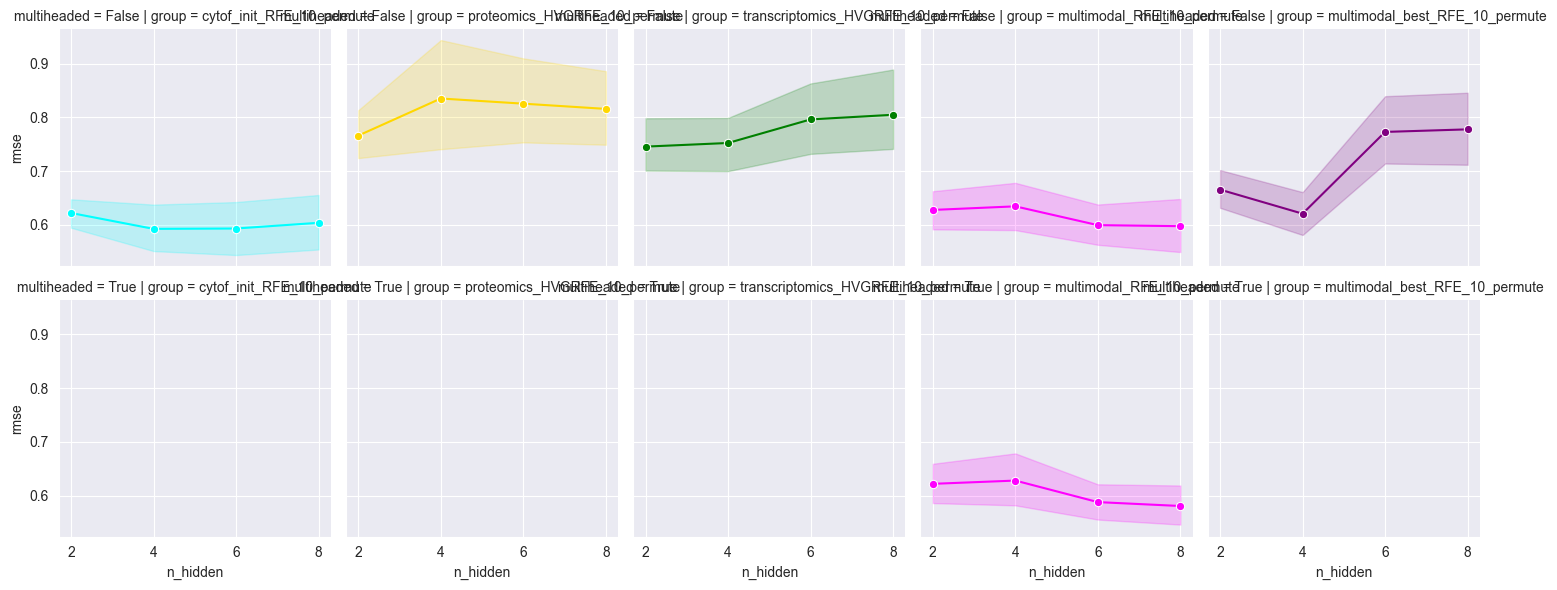

In [27]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_10_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_10_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [28]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [35]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=8.42, p-value=0.0380, significant? True
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=28.03, p-value=0.0000, significant? True
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.93, p-value=0.8176, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.53, p-value=0.9129, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.76, p-value=0.8598, significant? False


## Unclear + we cannot go larger than 10 because of number of features - leave untouched for now

# `depth` (fixed n_hidden = 2)

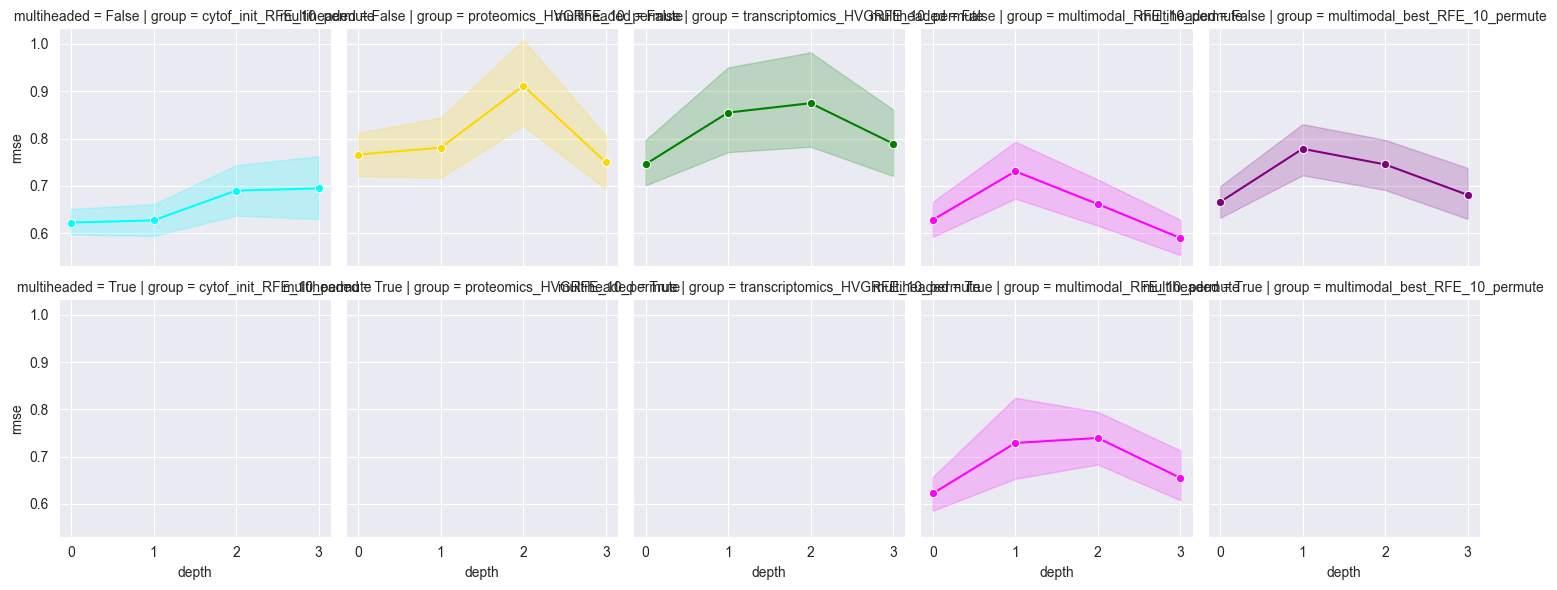

In [31]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [36]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "depth",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=21.00, p-value=0.0001, significant? True
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=13.99, p-value=0.0029, significant? True
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.57, p-value=0.6655, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=8.35, p-value=0.0392, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=4.25, p-value=0.2358, significant? False


## Bizarre up-down trend - would it go down below with increased depth? Try 4-5, but leave central value to 0

# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

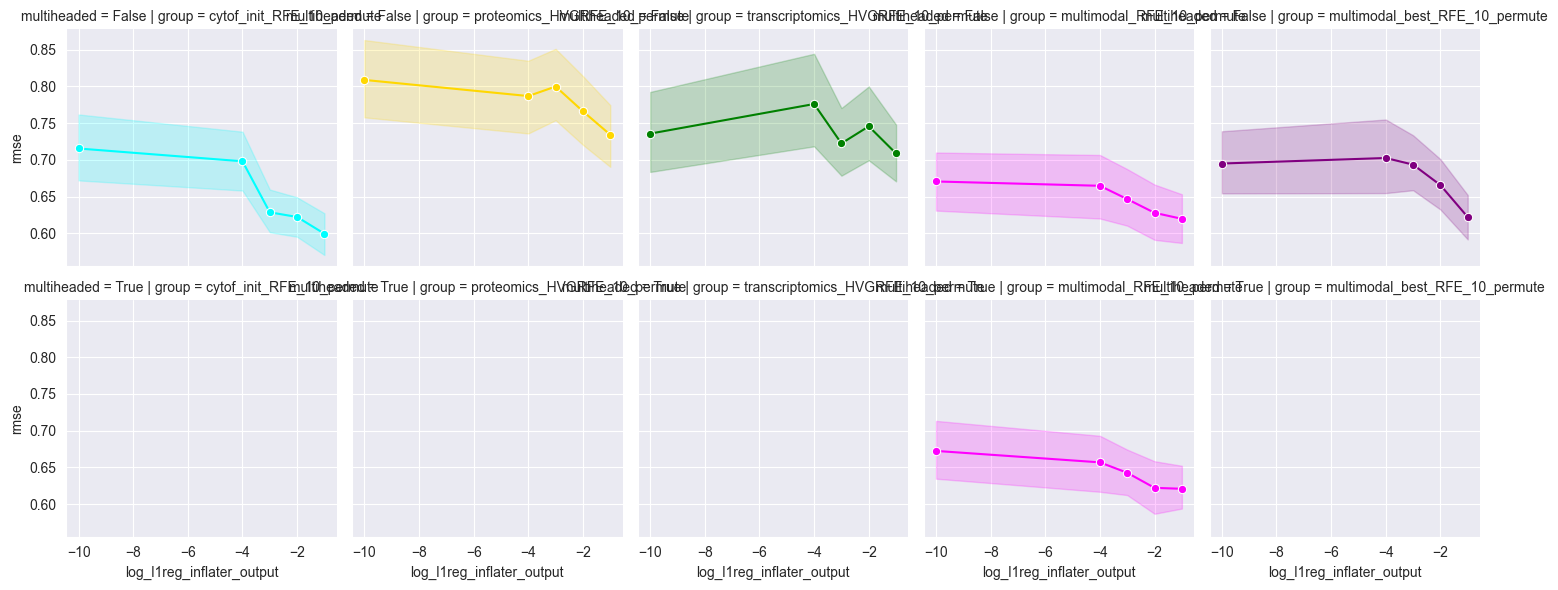

In [34]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [37]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=7.74, p-value=0.1016, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=9.35, p-value=0.0528, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.04, p-value=0.9041, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=6.20, p-value=0.1850, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=23.54, p-value=0.0001, significant? True


## Seems like it would be beneficial to test larger values (1e0, 1e1) + shift central value to max tested so far (1e-1)

# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

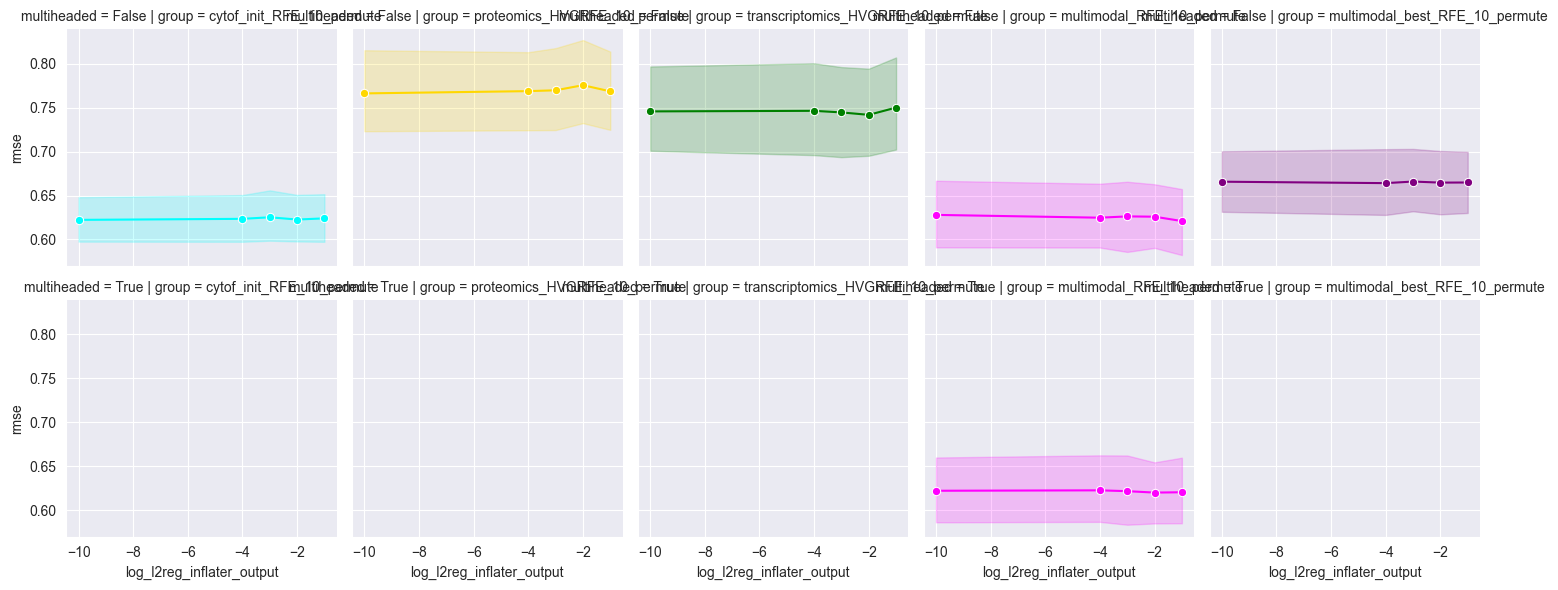

In [38]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [39]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.05, p-value=0.9997, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.04, p-value=0.9998, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.08, p-value=0.9992, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.12, p-value=0.9982, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.06, p-value=0.9996, significant? False


## Seems pretty unhelpful..

# Dropout Rate (`dropout_rate`)

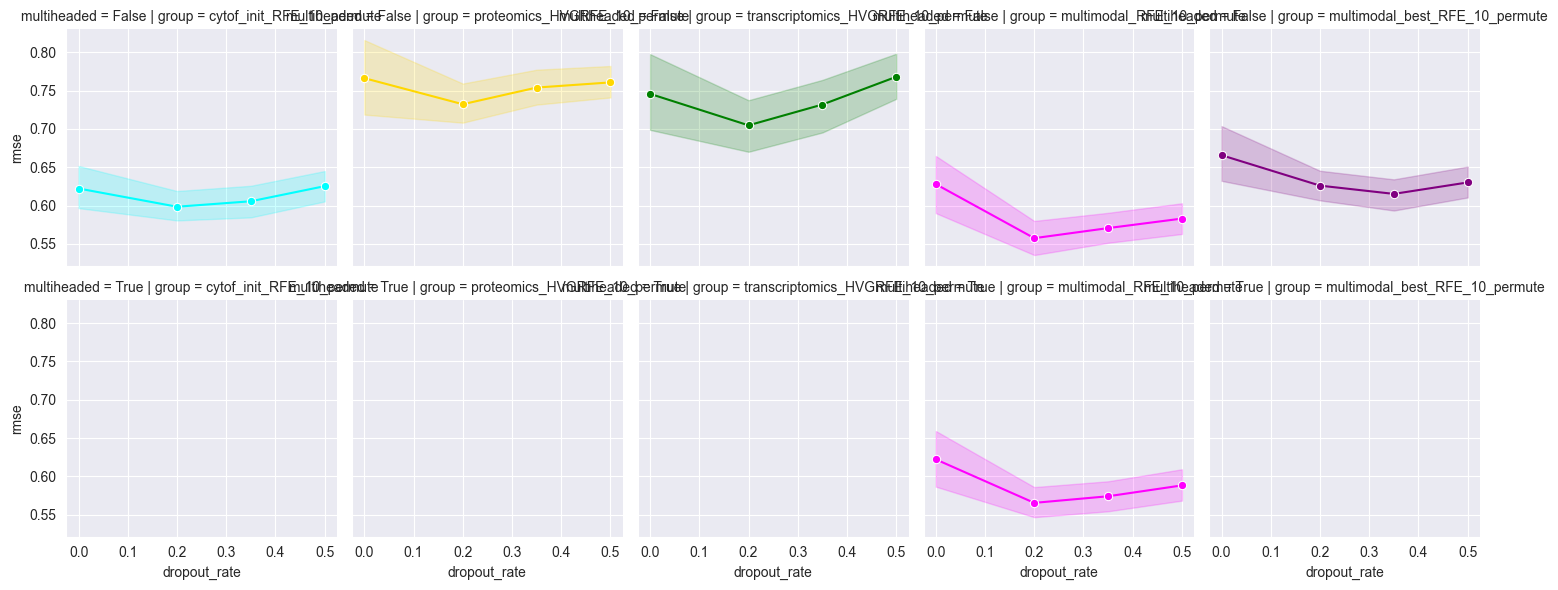

In [40]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="dropout_rate",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [43]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "dropout_rate",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=19.68, p-value=0.0002, significant? True
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.30, p-value=0.5119, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=7.52, p-value=0.0571, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=3.52, p-value=0.3177, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=3.65, p-value=0.3013, significant? False


## Seems like all contexts could benefit from 0.2 `dropout_rate` as central value

# Reconstruction loss (`recon_loss`)

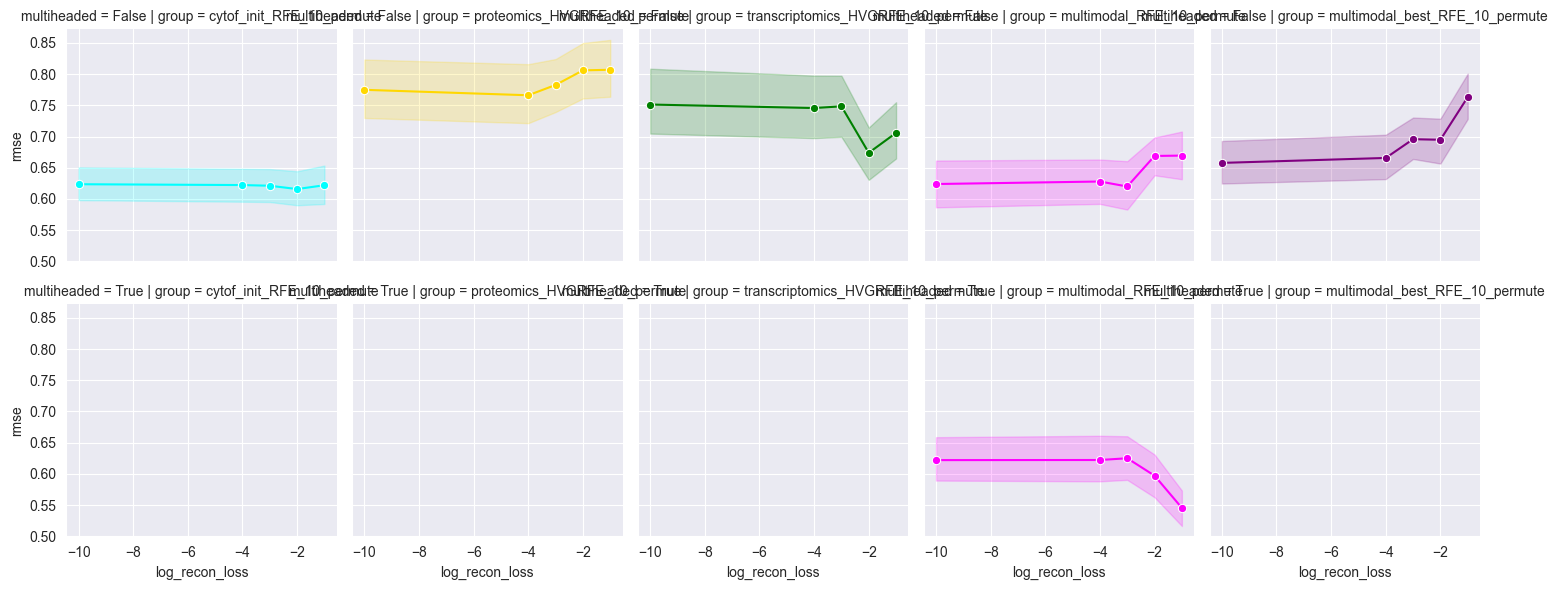

In [45]:
val_df["log_recon_loss"] = np.where(
    val_df["recon_loss"] != 0,
    np.log10(val_df["recon_loss"]),
    -10
)

g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.dropout_rate == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_recon_loss",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

## Seems pretty context-specific, but some cases, like the multiheaded multimodal (bottom), seem to benefit from very large values! -> increase range